In [1]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline

In [2]:
df=pd.read_csv("diamonds.csv")

In [3]:
df.head(10)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
5,6,0.24,Very Good,J,VVS2,62.8,57.0,336,3.94,3.96,2.48
6,7,0.24,Very Good,I,VVS1,62.3,57.0,336,3.95,3.98,2.47
7,8,0.26,Very Good,H,SI1,61.9,55.0,337,4.07,4.11,2.53
8,9,0.22,Fair,E,VS2,65.1,61.0,337,3.87,3.78,2.49
9,10,0.23,Very Good,H,VS1,59.4,61.0,338,4.00,4.05,2.39


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  object 
 3   color       53940 non-null  object 
 4   clarity     53940 non-null  object 
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.5+ MB


In [5]:
df.isnull().sum()

Unnamed: 0    0
carat         0
cut           0
color         0
clarity       0
depth         0
table         0
price         0
x             0
y             0
z             0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,53940.0,26970.500000,15571.281097,1.0,13485.75,26970.50,40455.25,53940.00
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [7]:
df.drop(df[df["x"]==0].index,inplace=True)
df.drop(df[df["y"]==0].index,inplace=True)
df.drop(df[df["z"]==0].index,inplace=True)

In [8]:
df.reset_index()

,index,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...,...,...
53915,53935,53936,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53916,53936,53937,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53917,53937,53938,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53918,53938,53939,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53920 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53920 non-null  int64  
 1   carat       53920 non-null  float64
 2   cut         53920 non-null  object 
 3   color       53920 non-null  object 
 4   clarity     53920 non-null  object 
 5   depth       53920 non-null  float64
 6   table       53920 non-null  float64
 7   price       53920 non-null  int64  
 8   x           53920 non-null  float64
 9   y           53920 non-null  float64
 10  z           53920 non-null  float64
dtypes: float64(6), int64(2), object(3)
memory usage: 4.9+ MB


In [10]:
corr=df.select_dtypes(include="number").corr()

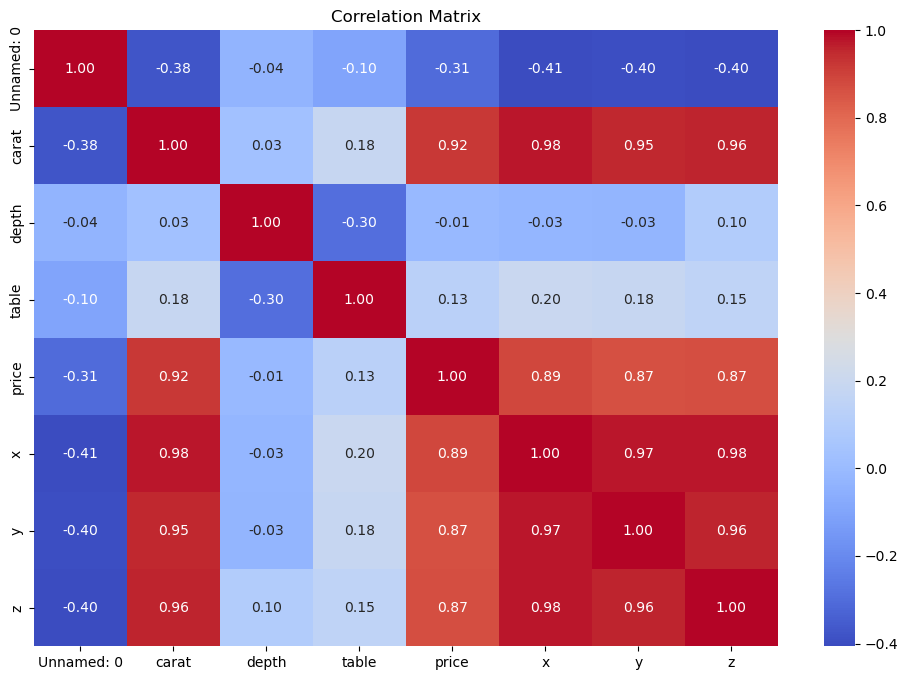

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [12]:
df.drop("Unnamed: 0",axis=1,inplace=True)

In [13]:
from sklearn.model_selection import GridSearchCV,train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

In [14]:
X=df.drop("price",axis=1)
y=df["price"]

In [15]:
numeric_columns = X.select_dtypes(include="number").columns
categorical_columns = X.select_dtypes(include=["object","string","category"]).columns

In [16]:
numeric_pipeline = Pipeline([
    ("scaler",StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("encoder",OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer([
    ("numeric",numeric_pipeline,numeric_columns),
    ("categoric",categorical_pipeline,categorical_columns)
])

In [17]:
SVC()

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [18]:
param_grid = {
    "C" : [0.01,0.1,1,10,100],
    "kernel" : ['linear', 'poly', 'rbf', 'sigmoid'],
    "gamma" : ["scale","auto"]
}

In [19]:
model_pipeline = Pipeline([
    ("preprocessor",preprocessor),
    ("grid",GridSearchCV(estimator=SVC(),param_grid=param_grid,cv=5,scoring="accuracy"))
])

In [20]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=15)